In [ ]:
# Squat Motion-Disentangling SSL (R(2+1)D-18, triplet distance-ratio pretext).
#
# Pretrains the backbone on unlabeled squat clips, then fine-tunes on the labeled
# KIE/KFE set. Reported metric: macro-F1 (paper §3.2/§5).
#
# Run in Colab on an L4 GPU (24 GB VRAM). Mounts the Drive shortcut
# `My Drive/Fitness-AQA_dataset_release` (reused — no new shortcut).
#
# The trajectory probe (first probe cell) confirms the unlabeled trajectory file
# format and the argmax-vs-argmin half-cycle SIGN on real clips before
# `squat_ssl._load_trajectory` is finalized and before any GPU pretraining. A wrong
# sign swaps descent/ascent and wastes the 12–24h run. Inspect the probe report and
# traj_probe.png before continuing.

# Squat Motion-Disentangling SSL

Self-supervised pretraining of an R(2+1)D-18 backbone on 4,970 unlabeled squat clips using a triplet distance-ratio pretext (descent vs. ascent half-cycles), then supervised fine-tuning on the labeled KIE/KFE set (Fitness-AQA, Parmar et al., ECCV 2022). Runs on an L4 GPU (24 GB) with per-epoch checkpointing to Drive.

## Setup

Clone the repo and add it to the Python path.

In [1]:
import os
import subprocess
import sys

REPO_DIR = "/content/fitnova"
REPO_URL = "https://github.com/Ibrahim-Shahin1/fitnova.git"
BRANCH = "fresh-start"

if not os.path.isdir(REPO_DIR):
    print(f"Cloning {REPO_URL} (branch {BRANCH}) -> {REPO_DIR} ...")
    subprocess.run(["git", "clone", "-b", BRANCH, REPO_URL, REPO_DIR], check=True)
else:
    print(f"Repo already at {REPO_DIR}; pulling latest from origin/{BRANCH} ...")
    subprocess.run(["git", "-C", REPO_DIR, "fetch", "origin", BRANCH], check=True)
    subprocess.run(["git", "-C", REPO_DIR, "checkout", BRANCH], check=True)
    subprocess.run(["git", "-C", REPO_DIR, "pull", "--ff-only", "origin", BRANCH], check=True)

os.chdir(REPO_DIR)
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

_head = subprocess.run(
    ["git", "-C", REPO_DIR, "rev-parse", "--short", "HEAD"],
    capture_output=True, text=True, check=True,
).stdout.strip()
print(f"\nRepo ready: {REPO_DIR} @ {_head}")
print(f"sys.path[0]: {sys.path[0]}")
print(f"cwd: {os.getcwd()}")

Cloning https://github.com/Ibrahim-Shahin1/fitnova.git (branch fresh-start) -> /content/fitnova ...

Repo ready: /content/fitnova @ edf508d
sys.path[0]: /content/fitnova
cwd: /content/fitnova


## Step 0 — environment, GPU check, and data staging

The next cell must import `_envinit` before `torch`, so `CUBLAS_WORKSPACE_CONFIG` is set before the CUDA context is created. It then probes dependency versions, asserts an L4 GPU, mounts Drive, and stages the 1,739 labeled clips plus the 4,970 unlabeled clips and their barbell trajectories.

In [2]:
from backend.training.aqa.harness import _envinit  # F8: sets CUBLAS_WORKSPACE_CONFIG before torch

import importlib.metadata
import os
import shutil
import subprocess
import sys

# PyAV before the first torch/torchvision import.
try:
    import av  # noqa: F401
    _pyav_status = "already installed"
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "av"], check=True)
    import av  # noqa: F401
    _pyav_status = "installed at startup"
print(f"PyAV {av.__version__} ({_pyav_status})")

# Dependency version probe (supply-chain guard). Zero new pip installs.
_PHASE4_DEPS = ["torch", "torchvision", "scikit-learn", "matplotlib", "tqdm", "numpy", "scipy"]
print("\nDependency versions (supply-chain guard):")
for _pkg in _PHASE4_DEPS:
    try:
        print(f"  {_pkg:<14} {importlib.metadata.version(_pkg)}")
    except importlib.metadata.PackageNotFoundError:
        raise RuntimeError(
            f"Dependency '{_pkg}' is NOT installed. This introduces "
            "zero new pip dependencies beyond PyAV — every package was already in "
            "backend/requirements.txt. If this fires, the Colab runtime is misconfigured."
        )

import torch
import torchvision

print("\npython     :", sys.version.split()[0])
print("torch      :", torch.__version__)
print("torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUBLAS_WORKSPACE_CONFIG:", os.environ.get("CUBLAS_WORKSPACE_CONFIG"))

# GPU + VRAM check.
assert torch.cuda.is_available(), (
    "GPU required — Runtime > Change runtime type > Hardware accelerator: L4"
)
_gpu_name = torch.cuda.get_device_name(0)
_vram_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
print(f"CUDA device : {_gpu_name} ({_vram_gb:.1f} GB VRAM)")
assert "L4" in _gpu_name or _vram_gb >= 22.0, (
    f"Expecting an L4 (>=22 GB); got {_gpu_name} {_vram_gb:.1f} GB. "
    "VRAM sizing assumes 24 GB headroom."
)

# Verify torchvision.io PyAV backend (no real video needed).
from torchvision.io.video import av as _tv_av_ref
assert not isinstance(_tv_av_ref, Exception), (
    "torchvision.io cached `av` as an Exception — PyAV install ordered wrong."
)
print("torchvision.io PyAV backend: ready")

# Drive mount (idempotent).
from google.colab import drive
drive.mount('/content/drive')
MYDRIVE = '/content/drive/MyDrive'
ROOT = os.path.join(MYDRIVE, 'Fitness-AQA_dataset_release')
print("\nROOT :", ROOT, "| exists:", os.path.exists(ROOT))

# Stage LABELED videos (1739 — reused for the linear-probe monitor).
from pathlib import Path
from backend.training.aqa.harness.colab import stage_squat_videos, stage_unlabeled_squat_videos

VIDEOS_ROOT = stage_squat_videos(MYDRIVE)
_labeled_n = len(list(Path(VIDEOS_ROOT).glob('*.mp4')))
print(f"\nLABELED VIDEOS_ROOT: {VIDEOS_ROOT} | mp4 count: {_labeled_n} (expected 1739)")
assert _labeled_n == 1739, f"Expected 1739 labeled mp4s, got {_labeled_n}"

# Log the unlabeled videos.zip size + free /content disk BEFORE staging the
# 4,970-clip set (it is ~4x the labeled set — confirm there is room).
_unlabeled_zip = Path(ROOT) / "Squat/Unlabeled_Dataset/videos.zip"
if _unlabeled_zip.is_file():
    print(f"\nunlabeled videos.zip: {_unlabeled_zip.stat().st_size / 1e9:.2f} GB")
_free_gb = shutil.disk_usage("/content").free / 1e9
print(f"free /content disk: {_free_gb:.1f} GB")

# Stage UNLABELED videos + barbell trajectories (4,970 — the SSL pretrain set).
UNLABELED_VIDEOS_ROOT, TRAJ_ROOT = stage_unlabeled_squat_videos(MYDRIVE)
_unlabeled_n = len(list(Path(UNLABELED_VIDEOS_ROOT).glob('*.mp4')))
print(f"\nUNLABELED_VIDEOS_ROOT: {UNLABELED_VIDEOS_ROOT} | mp4 count: {_unlabeled_n} (expected 4970)")
print(f"TRAJ_ROOT: {TRAJ_ROOT}")
assert _unlabeled_n == 4970, f"Expected 4970 unlabeled mp4s, got {_unlabeled_n}"

PyAV 17.0.1 (installed by Step 0)

[T-04-04] Dependency versions (supply-chain guard):
  torch          2.10.0+cu128
  torchvision    0.25.0+cu128
  scikit-learn   1.6.1
  matplotlib     3.10.0
  tqdm           4.67.3
  numpy          2.0.2
  scipy          1.16.3

python     : 3.12.13
torch      : 2.10.0+cu128
torchvision: 0.25.0+cu128
CUDA available: True
CUBLAS_WORKSPACE_CONFIG: :4096:8
CUDA device : NVIDIA L4 (22.0 GB VRAM)
torchvision.io PyAV backend: ready
Mounted at /content/drive

ROOT : /content/drive/MyDrive/Fitness-AQA_dataset_release | exists: True



LABELED VIDEOS_ROOT: /content/squat_videos | mp4 count: 1739 (expected 1739)

[T-04-08] unlabeled videos.zip: 1.68 GB
[T-04-08] free /content disk: 199.9 GB



UNLABELED_VIDEOS_ROOT: /content/squat_unlabeled_videos | mp4 count: 4970 (expected 4970)
TRAJ_ROOT: /content/squat_trajectories


## Step 1 — trajectory format and half-cycle-sign probe

Confirms the unlabeled trajectory file format and resolves the argmax-vs-argmin half-cycle sign before the SSL run: a wrong sign swaps descent and ascent. The probe reports archive structure, value type, raw-vs-smoothed signal, trajectory-length-to-frame-count mapping, and ID alignment; overlays `split_half_cycles` under both sign values on 3 sample clips with decoded descent/ascent frame grids; and counts multi-rep frequency across all 4,970 trajectories via `scipy.signal.find_peaks`.

In [ ]:
import glob
import json

import matplotlib.pyplot as plt
import numpy as np
import scipy.ndimage
import torch
import torchvision
from scipy.signal import find_peaks

from backend.training.aqa.datasets.squat_ssl import split_half_cycles
from backend.training.aqa.datasets.transforms import decode_clip

FIG_DIR = Path("docs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)


def _extract_y_series(data):
    """Defensively pull a 1-D y-trajectory out of whatever the JSON holds.

    Returns (y_series: np.ndarray, how: str) so the probe REPORTS the path taken
    rather than silently assuming a format.
    """
    arr = np.asarray(data, dtype=object)
    if isinstance(data, list) and data and isinstance(data[0], (int, float)):
        return np.asarray(data, dtype=float), "flat list of floats (== [ASSUMED])"
    if isinstance(data, list) and data and isinstance(data[0], (list, tuple)):
        cols = len(data[0])
        col = 1 if cols in (2, 4) else 0  # [x,y] or [x,y,w,h] -> y at index 1
        return np.asarray([row[col] for row in data], dtype=float), f"list of {cols}-tuples -> col {col}"
    if isinstance(data, dict):
        for key in ("y", "y_center", "cy", "centers", "trajectory", "traj"):
            if key in data:
                return _extract_y_series(data[key])[0], f"dict['{key}']"
        return np.asarray([], dtype=float), f"dict with keys {list(data.keys())[:8]} (UNHANDLED — describe below)"
    return np.asarray(arr, dtype=float).ravel(), "fallback ravel (UNHANDLED — describe below)"


# ── (1) Archive internal structure ───────────────────────────────────────────
all_traj = sorted(p for p in glob.glob(os.path.join(TRAJ_ROOT, "**", "*"), recursive=True) if os.path.isfile(p))
exts = {}
for p in all_traj:
    exts[Path(p).suffix.lower()] = exts.get(Path(p).suffix.lower(), 0) + 1
print(f"[structure] {len(all_traj)} trajectory files under {TRAJ_ROOT}")
print(f"  extensions: {exts}")
print(f"  sample names: {[os.path.basename(p) for p in all_traj[:5]]}")

# ── (2)+(3) Value type + raw/smoothed (load up to 5) ──────────────────────────
json_files = [p for p in all_traj if p.lower().endswith(".json")]
sample_files = json_files[:5] if json_files else all_traj[:5]
print(f"\n[value type] inspecting {len(sample_files)} files:")
parsed = []  # (clip_id, y_series, how)
for p in sample_files:
    try:
        with open(p) as fh:
            data = json.load(fh)
        y, how = _extract_y_series(data)
        parsed.append((Path(p).stem, y, how))
        print(f"  {Path(p).name}: top-type={type(data).__name__} -> y via {how}; "
              f"len={len(y)}, y[:3]={np.round(y[:3], 2).tolist()}, "
              f"range=[{y.min():.1f},{y.max():.1f}]" if len(y) else f"  {Path(p).name}: EMPTY/UNHANDLED ({how})")
    except Exception as e:  # noqa: BLE001
        print(f"  {Path(p).name}: NOT JSON or load error -> {e!r} (describe the real format below)")

# ── (5) ID alignment: do traj stems match clip IDs 1:1? ───────────────────────
traj_stems = {Path(p).stem for p in json_files} if json_files else {Path(p).stem for p in all_traj}
vid_stems = {p.stem for p in Path(UNLABELED_VIDEOS_ROOT).glob("*.mp4")}
print(f"\n[ID alignment] traj stems={len(traj_stems)} vid stems={len(vid_stems)} "
      f"| intersect={len(traj_stems & vid_stems)} | traj-only={len(traj_stems - vid_stems)} "
      f"| vid-only={len(vid_stems - traj_stems)}")

# ── (6) traj_nan list present in the unlabeled set? ───────────────────────────
_nan_candidates = [p for p in all_traj if "nan" in os.path.basename(p).lower()]
print(f"[traj_nan] files with 'nan' in name: {[os.path.basename(p) for p in _nan_candidates[:5]]} "
      f"(total {len(_nan_candidates)})")

# ── (4) traj length vs video frame count (mapping) for the sample clips ───────
import torchvision
print(f"\n[traj->frame mapping] (traj_len vs video_frame_count per clip):")
for clip_id, y, _how in parsed:
    if len(y) == 0:
        continue
    vpath = os.path.join(UNLABELED_VIDEOS_ROOT, f"{clip_id}.mp4")
    if not os.path.isfile(vpath):
        print(f"  {clip_id}: video not found at {vpath}")
        continue
    try:
        pts, _fps = torchvision.io.read_video_timestamps(vpath, pts_unit="sec")
        n_frames = len(pts)
        ratio = n_frames / len(y) if len(y) else float("nan")
        print(f"  {clip_id}: traj_len={len(y)}  video_frames={n_frames}  frames/traj={ratio:.3f} "
              f"({'1:1' if abs(ratio - 1.0) < 0.05 else 'NOT 1:1 — must rescale traj->frame'})")
    except Exception as e:  # noqa: BLE001
        print(f"  {clip_id}: read_video_timestamps failed -> {e!r}")

# ── SIGN DECISION figure: split overlay (both signs) + descent/ascent frame grids ──
n_show = min(3, sum(1 for _, y, _ in parsed if len(y) >= 4))
fig = plt.figure(figsize=(16, 4 * max(n_show, 1)))
row = 0
for clip_id, y, _how in parsed:
    if len(y) < 4:
        continue
    if row >= n_show:
        break
    sm = None
    try:
        import scipy.ndimage
        sm = scipy.ndimage.gaussian_filter1d(y, sigma=2.0)
    except Exception:
        sm = y
    b_max, b_min = int(np.argmax(sm)), int(np.argmin(sm))

    # Trajectory plot with BOTH candidate bottoms.
    ax = fig.add_subplot(n_show, 3, row * 3 + 1)
    ax.plot(y, color="0.6", lw=1, label="raw y")
    ax.plot(sm, color="C0", lw=2, label="smoothed")
    ax.axvline(b_max, color="C3", ls="--", label=f"argmax bottom @{b_max}")
    ax.axvline(b_min, color="C2", ls=":", label=f"argmin bottom @{b_min}")
    ax.set_title(f"{clip_id}  (len {len(y)})")
    ax.legend(fontsize=7)

    # Descent/ascent frame strips for the argmax sign (the [ASSUMED] default).
    vpath = os.path.join(UNLABELED_VIDEOS_ROOT, f"{clip_id}.mp4")
    try:
        desc, asc = split_half_cycles(y, frames_per_half=8, bottom_is_argmax=True)
        for j, (idxs, label, sub) in enumerate([(desc, "DESCENT (argmax)", 2), (asc, "ASCENT (argmax)", 3)]):
            clip = decode_clip(vpath, torch.as_tensor(np.asarray(idxs), dtype=torch.long))  # [T,3,H,W] uint8
            strip = torch.cat([clip[k] for k in range(min(8, clip.shape[0]))], dim=2)  # concat along W
            axg = fig.add_subplot(n_show, 3, row * 3 + sub)
            axg.imshow(strip.permute(1, 2, 0).numpy())
            axg.set_title(f"{label}  idx {np.asarray(idxs)[:4].tolist()}...", fontsize=8)
            axg.axis("off")
    except Exception as e:  # noqa: BLE001
        print(f"  [frame grid] {clip_id} failed: {e!r}")
    row += 1

fig.suptitle("Trajectory probe — confirm which sign puts the split at the rep-bottom (deepest squat)\n"
             "argmax (red --) vs argmin (green :) — and which makes DESCENT frames go DOWN", fontsize=11)
fig.tight_layout(rect=(0, 0, 1, 0.96))
_probe_png = FIG_DIR / "traj_probe.png"
fig.savefig(_probe_png, dpi=110, bbox_inches="tight")  # save BEFORE show (disconnect-safe)
print(f"\n[figure] saved {_probe_png}")
plt.show()

# ── multi-rep frequency across ALL 4,970 trajectories ──────
import scipy.ndimage
multi_rep = 0
total_ok = 0
for p in (json_files or all_traj):
    try:
        with open(p) as fh:
            y, _ = _extract_y_series(json.load(fh))
        if len(y) < 4:
            continue
        sm = scipy.ndimage.gaussian_filter1d(np.asarray(y, dtype=float), sigma=2.0)
        rng = sm.max() - sm.min()
        if rng <= 0:
            continue
        peaks, _ = find_peaks(sm, prominence=0.3 * rng)
        valleys, _ = find_peaks(-sm, prominence=0.3 * rng)
        total_ok += 1
        if (len(peaks) + len(valleys)) > 1:
            multi_rep += 1
    except Exception:  # noqa: BLE001
        continue
print(f"\n[multi-rep] {multi_rep}/{total_ok} trajectories have >1 prominent extremum "
      f"({100 * multi_rep / max(total_ok, 1):.1f}% — single-rep argmax/argmin covers the rest; "
      "find_peaks splitting is added only if this fraction is large)")

print("\n=== Probe complete — review this report, traj_probe.png, and the resolved sign. ===")

## Step 2 — SSL dataset smoke test

Instantiates `SquatSSLDataset`, pulls one batch via `build_ssl_loader`, and asserts the three `(B, 3, 16, 112, 112)` float32 triplet tensors. Renders an 8-frame strip of the raw anchor (descent) and negative (ascent) for one clip as a second visual check of the half-cycle split through the full data pipeline.

In [ ]:
import importlib

import matplotlib.pyplot as plt
import numpy as np
import torch

import backend.training.aqa.datasets.squat_ssl as _squat_ssl
importlib.reload(_squat_ssl)  # pick up code changes after git pull (sys.modules is stale)
from backend.training.aqa.datasets.squat_ssl import SquatSSLDataset, build_ssl_loader
from backend.training.aqa.harness.md_pretrain import MDConfig

_FIG_DIR = Path("docs/figures")
_FIG_DIR.mkdir(parents=True, exist_ok=True)

config = MDConfig()
ds = SquatSSLDataset(
    videos_root=UNLABELED_VIDEOS_ROOT,
    trajectories_root=TRAJ_ROOT,
    frames_per_half=config.frames_per_half,
    crop_size=config.crop_size,
)
print(f"len(ds) = {len(ds)} (expect ~4970)")

loader = build_ssl_loader(ds, config, seed=42)
batch = next(iter(loader))
_expected = (config.batch_size, 3, config.frames_per_half, config.crop_size, config.crop_size)
for _k in ("anchor", "positive", "negative"):
    _t = batch[_k]
    print(f"  {_k:>8}: shape={tuple(_t.shape)} dtype={_t.dtype}")
    assert tuple(_t.shape) == _expected, (_k, tuple(_t.shape), _expected)
    assert _t.dtype == torch.float32, (_k, _t.dtype)
print("triplet shapes ok")

# Sanity grid: decode the RAW descent/ascent for one clip (NO augs / NO temporal-reverse) so the
# half-cycle split is cleanly visible. The batch's anchor/negative are augmented AND randomly
# temporal-reversed (the global-motion equalizer), which would obscure the down/up direction —
# so the shapes are asserted from the batch (above), but the SPLIT is shown from the raw frames.
from backend.training.aqa.datasets.squat_ssl import split_half_cycles
from backend.training.aqa.datasets.transforms import decode_clip

_cid = ds._clip_ids[0]
_traj = ds._load_trajectory(_cid)
_desc, _asc = split_half_cycles(_traj, frames_per_half=config.frames_per_half, bottom_is_argmax=False)
_vp = os.path.join(UNLABELED_VIDEOS_ROOT, f"{_cid}.mp4")
_desc_u8 = decode_clip(_vp, torch.as_tensor(_desc, dtype=torch.long))  # [16,3,H,W] uint8
_asc_u8 = decode_clip(_vp, torch.as_tensor(_asc, dtype=torch.long))


def _u8_strip(clip_tchw: torch.Tensor, n: int = 8) -> np.ndarray:
    """[T,3,H,W] uint8 -> [H, n*W, 3] uint8 (n evenly-spaced frames) for imshow."""
    sel = torch.linspace(0, clip_tchw.shape[0] - 1, n).round().long()
    return np.concatenate([clip_tchw[t].permute(1, 2, 0).numpy() for t in sel], axis=1)


fig, axes = plt.subplots(2, 1, figsize=(16, 5))
axes[0].imshow(_u8_strip(_desc_u8))
axes[0].set_title(f"{_cid} DESCENT (frames {_desc[:4].tolist()}...) — lifter should be going DOWN")
axes[0].axis("off")
axes[1].imshow(_u8_strip(_asc_u8))
axes[1].set_title(f"{_cid} ASCENT (frames {_asc[:4].tolist()}...) — lifter should be going UP")
axes[1].axis("off")
fig.suptitle("SSL triplet sanity — RAW descent/ascent (confirms argmin on real data; batch shapes asserted above)")
fig.tight_layout()
_sanity_png = _FIG_DIR / "ssl_triplet_sanity.png"
fig.savefig(_sanity_png, dpi=110, bbox_inches="tight")  # save BEFORE show (disconnect-safe)
print(f"saved {_sanity_png}")
plt.show()

print("\n=== Smoke test complete — len(ds), the 3 shapes, and ssl_triplet_sanity.png are above. ===")

## Step 3 — VRAM probe

One forward+backward pass of the 3-branch triplet at batch size 8, then `max_memory_allocated`, to confirm peak memory fits the L4 budget before the full run.

In [ ]:
import importlib
import torch

import backend.training.aqa.datasets.squat_ssl as _sslds
import backend.training.aqa.harness.md_pretrain as _mdp
importlib.reload(_sslds)  # pick up the recursive-glob fix after git pull
importlib.reload(_mdp)     # pick up the finalized trainer after git pull
from backend.training.aqa.datasets.squat_ssl import SquatSSLDataset, build_ssl_loader
from backend.training.aqa.harness.md_pretrain import MDConfig, build_md_model, md_triplet_loss

config = MDConfig()
_dev = torch.device("cuda")
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

_bb, _proj = build_md_model()
_bb, _proj = _bb.to(_dev), _proj.to(_dev)
_ds = SquatSSLDataset(videos_root=UNLABELED_VIDEOS_ROOT, trajectories_root=TRAJ_ROOT,
                      frames_per_half=config.frames_per_half, crop_size=config.crop_size)
_b = next(iter(build_ssl_loader(_ds, config, seed=42)))
_opt = torch.optim.AdamW(list(_bb.parameters()) + list(_proj.parameters()),
                         lr=config.learning_rate, weight_decay=config.weight_decay)
_bb.train(); _proj.train()
_pa = _proj(_bb(_b["anchor"].to(_dev)))
_pp = _proj(_bb(_b["positive"].to(_dev)))
_pn = _proj(_bb(_b["negative"].to(_dev)))
_loss = md_triplet_loss(_pa, _pp, _pn, squared=config.loss_squared, three_term=config.loss_three_term)
_opt.zero_grad(); _loss.backward(); _opt.step()
_peak_gb = torch.cuda.max_memory_allocated() / 1e9
print(f"batch_size={config.batch_size} | peak backward VRAM = {_peak_gb:.2f} GB | loss = {_loss.item():.4f}")
assert _peak_gb < 22.0, f"VRAM {_peak_gb:.1f} GB exceeds the L4 budget — reduce batch size to 5"
print(f"VRAM fits L4 (< 22 GB) at batch {config.batch_size}")
del _bb, _proj, _opt, _pa, _pp, _pn, _loss, _b
torch.cuda.empty_cache()

## Step 4 — epoch-0 timing probe

One epoch under the production trainer to estimate total SSL training time. `epoch_wall_time_s` is the pure SSL-pass time (measured before the linear probe), so the estimate is `ssl_epoch_time * max_epochs`; the linear probe adds a smaller increment every 5 epochs.

In [ ]:
import os
import time

import torch

from backend.training.aqa.harness.md_pretrain import MDConfig, run_md_pretrain_epoch

config = MDConfig()
_t_cell = time.perf_counter()
_res = run_md_pretrain_epoch(
    run_name="md_pretrain_v1_timing",
    drive_root=MYDRIVE,
    videos_root=UNLABELED_VIDEOS_ROOT,
    trajectories_root=TRAJ_ROOT,
    labeled_videos_root=VIDEOS_ROOT,
    seed=42, config=config, resume=False, max_epochs=1,
)
_cell_wall = time.perf_counter() - _t_cell
_e0 = _res["metrics_history"][0]
_ssl_t = _e0["epoch_wall_time_s"]
_est_h = _ssl_t * config.max_epochs / 3600.0
print(f"epoch-0 SSL pass = {_ssl_t:.1f}s | full cell (incl. linear-probe) = {_cell_wall:.1f}s")
print(f"ssl_loss = {_e0['ssl_loss_mean']:.4f} | embedding_std = {_e0['embedding_std']:.5f} "
      f"(healthy ~{1/512**0.5:.5f}; collapse -> 0) | effective_rank = {_e0['effective_rank']:.1f}")
print(f"estimated SSL training time (x{config.max_epochs} epochs) = {_est_h:.1f} h "
      f"(+ linear-probe every {config.linear_probe_cadence} epochs)")
if _res["linear_probe_history"]:
    _lp = _res["linear_probe_history"][0]
    print(f"epoch-0 linear-probe macro-F1 = {_lp['linear_probe_f1_macro']:.4f} "
          f"(kie={_lp['linear_probe_f1_kie']:.4f} kfe={_lp['linear_probe_f1_kfe']:.4f})")

# Checkpoint round-trip verify.
_ckpt = _res["checkpoint_path"]
print(f"\ncheckpoint: {_ckpt} ({os.path.getsize(_ckpt) / 1e6:.1f} MB)")
_pl = torch.load(_ckpt, map_location="cpu", weights_only=False)
assert _pl["code_version"] == "phase04-md-pretrain", _pl.get("code_version")
print("checkpoint round-trip OK; payload keys:", sorted(_pl.keys()))

print(f"\n=== Timing estimate: est_total≈{_est_h:.1f}h, VRAM fits. "
      "batch 8 if ≤~18h; batch 5 if >24h or VRAM tight; "
      "TorchCodec only if GPU<50% util (decode-bound). ===")

## Step 5 — full MD-SSL pretraining

Batch 8, 60-epoch cosine schedule, linear probe every 5 epochs. `resume=True` makes the run recoverable across Colab disconnects, checkpointing every epoch to Drive and writing `backbone.pt` on each linear-probe-macro improvement. Health checks: SSL loss should decrease, `embedding_std` should stay above 0.1/sqrt(512) (no collapse, paper §12), and `effective_rank` should not fall toward 1; training stops once the linear-probe macro-F1 plateaus.

In [ ]:
import importlib

import backend.training.aqa.harness.md_pretrain as _mdp
importlib.reload(_mdp)  # pick up the latest trainer + the collapse-metric fix after git pull
from backend.training.aqa.harness.md_pretrain import MDConfig, run_md_pretrain_epoch

config = MDConfig()  # batch 8, 60-epoch cosine, linear_probe_cadence=5
RUN_NAME = "md_pretrain_v1"
result = run_md_pretrain_epoch(
    run_name=RUN_NAME,
    drive_root=MYDRIVE,
    videos_root=UNLABELED_VIDEOS_ROOT,
    trajectories_root=TRAJ_ROOT,
    labeled_videos_root=VIDEOS_ROOT,
    seed=42, config=config, resume=True, max_epochs=config.max_epochs,
)

print(f"\nfinal epoch = {result['epoch']} | collapsed = {result['collapsed']}")
print(f"backbone.pt = {result['backbone_path']}")
print("\nlinear-probe history (watch macro rise then plateau — the convergence stop):")
for _e in result["linear_probe_history"]:
    print(f"  epoch {_e['epoch']:>2}: macro={_e['linear_probe_f1_macro']:.4f} "
          f"(kie={_e['linear_probe_f1_kie']:.4f} kfe={_e['linear_probe_f1_kfe']:.4f})")
print("\nssl_loss + collapse trend (loss down; emb_std not -> 0; eff_rank not -> 1):")
for _m in result["metrics_history"]:
    print(f"  epoch {_m['epoch']:>2}: ssl_loss={_m['ssl_loss_mean']:.4f} "
          f"emb_std={_m['embedding_std']:.5f} eff_rank={_m['effective_rank']:.1f}")

In [3]:
# The SSL output isn't gone — it's on Drive. This reprints it from the checkpoint.
from google.colab import drive; drive.mount('/content/drive')
import os, torch
run_dir = "/content/drive/MyDrive/FitNova/checkpoints/phase04/md_pretrain_v2"
print("files on Drive:", sorted(os.listdir(run_dir)))
with open(os.path.join(run_dir, "latest.txt")) as f: name = f.read().strip()
ck = torch.load(os.path.join(run_dir, name), map_location="cpu", weights_only=False)
print(f"\nrecovered {name} (last epoch {ck['epoch']})")
print("v2 linear-probe curve:")
for e in ck["linear_probe_history"]:
    print(f"  ep {e['epoch']:>2}: macro={e['linear_probe_f1_macro']:.4f} "
          f"(kie={e['linear_probe_f1_kie']:.4f} kfe={e['linear_probe_f1_kfe']:.4f})")
bb = os.path.join(run_dir, "backbone.pt")
print(f"\nbackbone.pt: {os.path.isfile(bb)} ({os.path.getsize(bb)/1e6:.0f} MB) — fine-tune loads this")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
files on Drive: ['backbone.pt', 'epoch_017.pt', 'epoch_018.pt', 'epoch_019.pt', 'latest.txt']

recovered epoch_019.pt (last epoch 19)
v2 linear-probe curve:
  ep  0: macro=0.5143 (kie=0.3299 kfe=0.6987)
  ep  5: macro=0.5844 (kie=0.4554 kfe=0.7133)
  ep 10: macro=0.5443 (kie=0.3486 kfe=0.7400)
  ep 15: macro=0.5605 (kie=0.4000 kfe=0.7211)

backbone.pt: True (380 MB) — fine-tune loads this


In [4]:
# ═══ Fine-tune — SETUP + SANITY ═══
# Re-run the setup cell first (pulls the latest md_finetune code), then the environment cell if reconnected.
import importlib, os, torch
import backend.training.aqa.harness.supervised_train as _sup; importlib.reload(_sup)
import backend.training.aqa.harness.md_finetune as _mft;     importlib.reload(_mft)
from torch.utils.data import DataLoader
from backend.training.aqa.datasets.squat import SquatKIEKFEDataset

MD_BACKBONE = os.path.join(MYDRIVE, "FitNova/checkpoints/phase04/md_pretrain_v2/backbone.pt")
assert os.path.isfile(MD_BACKBONE), f"backbone not found: {MD_BACKBONE}"
_ck = torch.load(MD_BACKBONE, map_location="cpu", weights_only=False)
print(f"MD backbone = md_pretrain_v2/backbone.pt (epoch={_ck['epoch']}, expect 5)")

device = torch.device("cuda")
model = _mft.build_finetune_model(MD_BACKBONE, dropout=0.2).to(device).eval()
print("fine-tune head:", model.fc)   # expect Sequential(Dropout(p=0.2), Linear(512->2))

# sanity: one real labeled VAL batch -> logits [B, 2]
ds = SquatKIEKFEDataset(split="val", train_aug=False, drive_root=MYDRIVE,
                        videos_root=VIDEOS_ROOT, num_frames=32, crop_size=112)
clip, label = next(iter(DataLoader(ds, batch_size=4, num_workers=0, shuffle=False)))
with torch.no_grad():
    logits = model(clip.to(device))
print(f"forward OK: clip {tuple(clip.shape)} -> logits {tuple(logits.shape)} (expect (4, 2))")
print(f"val set size={len(ds)}  pos_weight(KIE,KFE)={ds.pos_weight.tolist()}")

MD backbone = md_pretrain_v2/backbone.pt (epoch=5, expect 5)
fine-tune head: Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=512, out_features=2, bias=True)
)
forward OK: clip (4, 3, 32, 112, 112) -> logits (4, 2) (expect (4, 2))
val set size=243  pos_weight(KIE,KFE)=[6.099999904632568, 0.4526854157447815]


In [5]:
# ═══ seed 42 timing probe (1 real epoch, resume-safe) ═══
config = _mft.FinetuneConfig(max_epochs=50)   # AdamW lr1e-4 wd1e-4 dropout0.2, 50ep/8-patience, cosine T_max=50
res = _mft.run_md_finetune_epoch(
    run_name="md_finetune_seed42",
    md_backbone_path=MD_BACKBONE,
    drive_root=MYDRIVE, videos_root=VIDEOS_ROOT,
    seed=42, config=config, resume=True, max_epochs=1,   # epoch 0 only; the full run resumes to 50
)
m0 = res["metrics_history"][-1]
print(f"\nepoch {m0['epoch']}: wall={m0['epoch_wall_time_s']:.0f}s")
print(f"  train_loss={m0['train_loss_mean']:.4f}  val_loss={m0['val_loss_mean']:.4f}  "
      f"train/val ratio={m0['train_val_loss_ratio']:.2f}  (aborts if >10 before ep10)")
print(f"  val_macro_f1={m0['val_macro_f1']:.4f} (kie={m0['val_f1_kie']:.4f} kfe={m0['val_f1_kfe']:.4f})")
print(f"  aborted_overfit={res['aborted_overfit']}")
_w = m0['epoch_wall_time_s']
print(f"\nest per-seed (~13 epochs w/ early-stop) ≈ {_w*13/60:.0f} min; 3 seeds ≈ {_w*13*3/60:.0f} min")


epoch 0: wall=364s
  train_loss=0.7890  val_loss=0.7727  train/val ratio=1.02  (D6 aborts if >10 before ep10)
  val_macro_f1=0.5462 (kie=0.3624 kfe=0.7300)
  aborted_overfit=False

est per-seed (~13 epochs w/ early-stop) ≈ 79 min; 3 seeds ≈ 237 min


In [6]:
# ═══ seed 42 full fine-tune (resume ep1 -> 50, self early-stops) ═══
config = _mft.FinetuneConfig(max_epochs=50)   # same config as the probe (config_hash must match to resume)
res42 = _mft.run_md_finetune_epoch(
    run_name="md_finetune_seed42",
    md_backbone_path=MD_BACKBONE,
    drive_root=MYDRIVE, videos_root=VIDEOS_ROOT,
    seed=42, config=config, resume=True, max_epochs=50,
)
print(f"\nseed 42 DONE: final epoch={res42['epoch']}  best_val_macro_f1={res42['best_f1_val']:.4f}  "
      f"aborted_overfit={res42['aborted_overfit']}")
print(f"best.pt = {res42['best_checkpoint_path']}")
print("\nval macro-F1 curve (early-stop peak = the best.pt epoch):")
for m in res42["metrics_history"]:
    print(f"  ep {m['epoch']:>2}: train={m['train_loss_mean']:.3f} val={m['val_loss_mean']:.3f} "
          f"ratio={m['train_val_loss_ratio']:.2f} macro={m['val_macro_f1']:.4f} "
          f"(kie={m['val_f1_kie']:.4f} kfe={m['val_f1_kfe']:.4f})")

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a226478dee0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a226478dee0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a226478dee0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a226478dee0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16


seed 42 DONE: final epoch=16  best_val_macro_f1=0.6062  aborted_overfit=False
best.pt = /content/drive/MyDrive/FitNova/checkpoints/phase04/md_finetune_seed42/best.pt

val macro-F1 curve (early-stop peak = the best.pt epoch):
  ep  0: train=0.789 val=0.773 ratio=1.02 macro=0.5462 (kie=0.3624 kfe=0.7300)
  ep  1: train=0.666 val=0.722 ratio=0.92 macro=0.5595 (kie=0.3761 kfe=0.7429)
  ep  2: train=0.689 val=0.770 ratio=0.90 macro=0.5569 (kie=0.3740 kfe=0.7398)
  ep  3: train=0.624 val=0.726 ratio=0.86 macro=0.5682 (kie=0.4231 kfe=0.7133)
  ep  4: train=0.561 val=0.705 ratio=0.80 macro=0.5969 (kie=0.4286 kfe=0.7653)
  ep  5: train=0.460 val=1.075 ratio=0.43 macro=0.5334 (kie=0.3797 kfe=0.6871)
  ep  6: train=0.418 val=1.146 ratio=0.36 macro=0.5595 (kie=0.3571 kfe=0.7619)
  ep  7: train=0.357 val=1.543 ratio=0.23 macro=0.5553 (kie=0.3810 kfe=0.7297)
  ep  8: train=0.331 val=1.127 ratio=0.29 macro=0.6062 (kie=0.4112 kfe=0.8011)
  ep  9: train=0.337 val=1.012 ratio=0.33 macro=0.5228 (kie=0.3

In [3]:
# ═══ seed 1337 fine-tune (base recipe; resume-safe) ═══
# If reconnected, run the setup + environment cells first (defines MYDRIVE/VIDEOS_ROOT + re-stages labeled), then this.
import importlib, os
import backend.training.aqa.harness.supervised_train as _sup; importlib.reload(_sup)
import backend.training.aqa.harness.md_finetune as _mft;     importlib.reload(_mft)

MD_BACKBONE = os.path.join(MYDRIVE, "FitNova/checkpoints/phase04/md_pretrain_v2/backbone.pt")
config = _mft.FinetuneConfig(max_epochs=50)   # base recipe (seed 42 stayed within the overfit guard)
res = _mft.run_md_finetune_epoch(
    run_name="md_finetune_seed1337",
    md_backbone_path=MD_BACKBONE,
    drive_root=MYDRIVE, videos_root=VIDEOS_ROOT,
    seed=1337, config=config, resume=True, max_epochs=50,
)
print(f"\nseed 1337 DONE: final epoch={res['epoch']}  best_val_macro_f1={res['best_f1_val']:.4f}  "
      f"aborted_overfit={res['aborted_overfit']}")
print(f"best.pt = {res['best_checkpoint_path']}")
print("\nval macro-F1 curve:")
for m in res["metrics_history"]:
    print(f"  ep {m['epoch']:>2}: train={m['train_loss_mean']:.3f} val={m['val_loss_mean']:.3f} "
          f"val/train={m['val_train_loss_ratio']:.2f} macro={m['val_macro_f1']:.4f} "
          f"(kie={m['val_f1_kie']:.4f} kfe={m['val_f1_kfe']:.4f})")


seed 1337 DONE: final epoch=10  best_val_macro_f1=0.6055  aborted_overfit=False
best.pt = /content/drive/MyDrive/FitNova/checkpoints/phase04/md_finetune_seed1337/best.pt

val macro-F1 curve:
  ep  0: train=0.803 val=0.718 val/train=0.89 macro=0.5883 (kie=0.3846 kfe=0.7920)
  ep  1: train=0.736 val=0.807 val/train=1.10 macro=0.5351 (kie=0.2936 kfe=0.7765)
  ep  2: train=0.657 val=0.692 val/train=1.05 macro=0.6055 (kie=0.4310 kfe=0.7801)
  ep  3: train=0.597 val=0.712 val/train=1.19 macro=0.5881 (kie=0.3871 kfe=0.7890)
  ep  4: train=0.533 val=0.796 val/train=1.49 macro=0.5765 (kie=0.3667 kfe=0.7863)
  ep  5: train=0.475 val=1.136 val/train=2.39 macro=0.5550 (kie=0.3229 kfe=0.7871)
  ep  6: train=0.416 val=0.819 val/train=1.97 macro=0.5602 (kie=0.3962 kfe=0.7241)
  ep  7: train=0.322 val=1.035 val/train=3.22 macro=0.5822 (kie=0.3947 kfe=0.7697)
  ep  8: train=0.329 val=1.076 val/train=3.27 macro=0.5614 (kie=0.3355 kfe=0.7874)
  ep  9: train=0.307 val=1.199 val/train=3.90 macro=0.5642 (k

In [3]:
# ═══ seed 7 fine-tune (base recipe; resume-safe) — the last seed ═══
# If reconnected, run the setup + environment cells first, then this.
import importlib, os
import backend.training.aqa.harness.supervised_train as _sup; importlib.reload(_sup)
import backend.training.aqa.harness.md_finetune as _mft;     importlib.reload(_mft)

MD_BACKBONE = os.path.join(MYDRIVE, "FitNova/checkpoints/phase04/md_pretrain_v2/backbone.pt")
config = _mft.FinetuneConfig(max_epochs=50)   # base recipe (homogeneous 3-seed ensemble)
res = _mft.run_md_finetune_epoch(
    run_name="md_finetune_seed7",
    md_backbone_path=MD_BACKBONE,
    drive_root=MYDRIVE, videos_root=VIDEOS_ROOT,
    seed=7, config=config, resume=True, max_epochs=50,
)
print(f"\nseed 7 DONE: final epoch={res['epoch']}  best_val_macro_f1={res['best_f1_val']:.4f}  "
      f"aborted_overfit={res['aborted_overfit']}")
print(f"best.pt = {res['best_checkpoint_path']}")
print("\nval macro-F1 curve:")
for m in res["metrics_history"]:
    print(f"  ep {m['epoch']:>2}: train={m['train_loss_mean']:.3f} val={m['val_loss_mean']:.3f} "
          f"val/train={m['val_train_loss_ratio']:.2f} macro={m['val_macro_f1']:.4f} "
          f"(kie={m['val_f1_kie']:.4f} kfe={m['val_f1_kfe']:.4f})")


seed 7 DONE: final epoch=16  best_val_macro_f1=0.6169  aborted_overfit=False
best.pt = /content/drive/MyDrive/FitNova/checkpoints/phase04/md_finetune_seed7/best.pt

val macro-F1 curve:
  ep  0: train=0.785 val=0.754 val/train=0.96 macro=0.5618 (kie=0.3316 kfe=0.7919)
  ep  1: train=0.711 val=0.682 val/train=0.96 macro=0.5710 (kie=0.3626 kfe=0.7794)
  ep  2: train=0.637 val=0.743 val/train=1.17 macro=0.5553 (kie=0.4286 kfe=0.6821)
  ep  3: train=0.593 val=0.758 val/train=1.28 macro=0.5283 (kie=0.4065 kfe=0.6500)
  ep  4: train=0.527 val=0.748 val/train=1.42 macro=0.5927 (kie=0.4400 kfe=0.7455)
  ep  5: train=0.480 val=0.735 val/train=1.53 macro=0.5983 (kie=0.4545 kfe=0.7421)
  ep  6: train=0.446 val=0.801 val/train=1.80 macro=0.5528 (kie=0.3788 kfe=0.7267)
  ep  7: train=0.391 val=0.950 val/train=2.43 macro=0.5634 (kie=0.4348 kfe=0.6920)
  ep  8: train=0.331 val=0.903 val/train=2.73 macro=0.6169 (kie=0.4932 kfe=0.7407)
  ep  9: train=0.310 val=1.094 val/train=3.53 macro=0.5900 (kie=0.4

In [3]:
# ═══ base ensemble TEST eval (3 seeds, mean-of-sigmoids, val-tuned threshold) ═══
# If reconnected, run the setup + environment cells first. Needs 3 best.pt + md_pretrain_v2/backbone.pt on Drive.
import importlib, os, numpy as np, torch
from torch.utils.data import DataLoader
try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(x, **k): return x
import backend.training.aqa.harness.supervised_train as _sup; importlib.reload(_sup)
import backend.training.aqa.harness.md_finetune   as _mft; importlib.reload(_mft)
from backend.training.aqa.datasets.squat import SquatKIEKFEDataset
from backend.training.aqa.eval.ensemble import aggregate_sigmoid_mean
from backend.training.aqa.eval.metrics import threshold_sweep, f1_per_error, pr_auc_per_error

device = torch.device("cuda")
MD_BACKBONE = os.path.join(MYDRIVE, "FitNova/checkpoints/phase04/md_pretrain_v2/backbone.pt")
SEEDS = [42, 1337, 7]

def _load_ft(seed):  # architecture from build_finetune_model, weights from the fine-tuned best.pt
    ck = torch.load(os.path.join(MYDRIVE, f"FitNova/checkpoints/phase04/md_finetune_seed{seed}/best.pt"),
                    map_location="cpu", weights_only=False)
    m = _mft.build_finetune_model(MD_BACKBONE, dropout=0.2)
    m.load_state_dict(ck["model_state_dict"])
    return m.to(device).eval(), float(ck["best_f1_val"]), int(ck["epoch"])

models = []
for s in SEEDS:
    m, vb, ep = _load_ft(s); models.append(m)
    print(f"seed {s}: best.pt epoch={ep} val_macro={vb:.4f}")

def _forward_all(split):
    ds = SquatKIEKFEDataset(split=split, train_aug=False, drive_root=MYDRIVE,
                            videos_root=VIDEOS_ROOT, num_frames=32, crop_size=112)
    loader = DataLoader(ds, batch_size=16, num_workers=4, shuffle=False, drop_last=False)
    outs = [[] for _ in models]; labs = []
    with torch.no_grad():
        for clip, label in tqdm(loader, desc=f"{split} ({len(ds)} clips x3 models)"):
            clip = clip.to(device, non_blocking=True)
            for i, mdl in enumerate(models):
                outs[i].append(mdl(clip).cpu().numpy())
            labs.append(label.numpy())
    return [np.concatenate(o) for o in outs], np.concatenate(labs).astype(int)

val_logits, val_y = _forward_all("val")
test_logits, test_y = _forward_all("test")

ens_val  = aggregate_sigmoid_mean(val_logits)    # mean-of-sigmoids -> [0,1]
ens_test = aggregate_sigmoid_mean(test_logits)

heads = ["KIE", "KFE"]; thr = {}; val_f1 = {}; test_f1 = {}
for h, name in enumerate(heads):
    t, vf1 = threshold_sweep(val_y[:, h], ens_val[:, h])   # tuned on ENSEMBLE VAL
    thr[name], val_f1[name] = t, vf1
    test_f1[name] = f1_per_error(test_y[:, h], (ens_test[:, h] >= t).astype(int))  # applied to TEST
ens_val_macro  = (val_f1["KIE"] + val_f1["KFE"]) / 2
ens_test_macro = (test_f1["KIE"] + test_f1["KFE"]) / 2
prauc = {name: pr_auc_per_error(test_y[:, h], ens_test[:, h]) for h, name in enumerate(heads)}

print("\n══ val-tuned thresholds:", {k: round(v, 3) for k, v in thr.items()})
print(f"ensemble VAL macro  = {ens_val_macro:.4f}")
print(f"ensemble TEST macro = {ens_test_macro:.4f}  (KIE {test_f1['KIE']:.4f} / KFE {test_f1['KFE']:.4f})")
print(f"ensemble TEST PR-AUC: KIE {prauc['KIE']:.4f} / KFE {prauc['KFE']:.4f}")
print("\nper-seed TEST macro @ ensemble thresholds (variance):")
for i, s in enumerate(SEEDS):
    sig = 1/(1+np.exp(-test_logits[i]))
    f = [f1_per_error(test_y[:, h], (sig[:, h] >= thr[heads[h]]).astype(int)) for h in range(2)]
    print(f"  seed {s}: macro={(f[0]+f[1])/2:.4f} (KIE {f[0]:.4f} / KFE {f[1]:.4f})")

gap = abs(ens_val_macro - ens_test_macro)
print("\n── post-hoc monitors ──")
print(f"  val-test macro gap = {gap:.4f}  ({'OK <0.05' if gap < 0.05 else 'WIDE — over-tuned to val'})")
print(f"  KIE test F1 = {test_f1['KIE']:.4f}  ({'OK >=0.2857' if test_f1['KIE'] >= 0.2857 else 'REGRESSION vs Kinetics baseline'})")
print("\n── headline (test macro) ──")
print(f"  Kinetics baseline 0.5429 | paper Kinetics 0.5577 | paper MD 0.6262")
print(f"  MD-SSL ENSEMBLE    {ens_test_macro:.4f}   (no TTA yet — val-tuned TTA evaluated separately)")

seed 42: best.pt epoch=8 val_macro=0.6062
seed 1337: best.pt epoch=2 val_macro=0.6055
seed 7: best.pt epoch=8 val_macro=0.6169


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x798cf179a020>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x798cf179a020>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16


══ val-tuned thresholds: {'KIE': 0.614, 'KFE': 0.385}
ensemble VAL macro  = 0.6564
ensemble TEST macro = 0.6304  (KIE 0.4198 / KFE 0.8410)
ensemble TEST PR-AUC: KIE 0.3875 / KFE 0.8812

per-seed TEST macro @ ensemble thresholds (variance):
  seed 42: macro=0.6115 (KIE 0.3966 / KFE 0.8265)
  seed 1337: macro=0.6121 (KIE 0.3962 / KFE 0.8279)
  seed 7: macro=0.5691 (KIE 0.3226 / KFE 0.8156)

── D6 post-hoc monitors ──
  val-test macro gap = 0.0260  (OK <0.05)
  KIE test F1 = 0.4198  (OK >=0.2857)

── headline (test macro) ──
  Phase 3 (Kinetics) 0.5429 | paper Kinetics 0.5577 | paper MD 0.6262
  Phase 4 ENSEMBLE   0.6304   (no TTA yet — Step 8 adds val-tuned TTA)


In [4]:
# ═══ val-tuned TTA (select recipe on ensemble VAL, apply to TEST) ═══
# Builds on the base-ensemble cell (reuses `models`, np, torch, loaders, primitives). Re-run that cell if the kernel reset.
import itertools

VIEWS = ["orig", "temporal_jitter", "flip"]  # 5-crop omitted: inline-upsample fidelity caveat (tta.py docstring)

def _view(clip, v):  # clip [B,3,T,H,W]
    if v == "orig":            return clip
    if v == "temporal_jitter": return torch.roll(clip, shifts=1, dims=2)   # roll T
    if v == "flip":            return torch.flip(clip, dims=(-1,))          # mirror W
    raise ValueError(v)

def _cache_views(split):
    ds = SquatKIEKFEDataset(split=split, train_aug=False, drive_root=MYDRIVE,
                            videos_root=VIDEOS_ROOT, num_frames=32, crop_size=112)
    loader = DataLoader(ds, batch_size=16, num_workers=4, shuffle=False, drop_last=False)
    cache = {i: {v: [] for v in VIEWS} for i in range(len(models))}
    labs = []
    with torch.no_grad():
        for clip, label in tqdm(loader, desc=f"{split} TTA ({len(ds)} clips x{len(models)}m x{len(VIEWS)}v)"):
            clip = clip.to(device, non_blocking=True); labs.append(label.numpy())
            for v in VIEWS:
                cv = _view(clip, v)
                for i, m in enumerate(models):
                    cache[i][v].append(m(cv).cpu().numpy())
    for i in cache:
        for v in VIEWS: cache[i][v] = np.concatenate(cache[i][v])
    return cache, np.concatenate(labs).astype(int)

val_cache, vy = _cache_views("val")
test_cache, ty = _cache_views("test")

def _ensemble_under(cache, recipe):  # recipe = views incl "orig": mean-logits per seed -> mean-of-sigmoids
    per_seed = [np.mean([cache[i][v] for v in recipe], axis=0) for i in range(len(models))]
    return aggregate_sigmoid_mean(per_seed)

extra = [v for v in VIEWS if v != "orig"]
candidates = [("orig",)] + [("orig", *c) for r in range(1, len(extra)+1)
                            for c in itertools.combinations(extra, r)]

print("recipe selection on ensemble VAL macro:")
best = None
for recipe in candidates:
    ens = _ensemble_under(val_cache, recipe)
    macro = float(np.mean([threshold_sweep(vy[:, h], ens[:, h])[1] for h in range(2)]))
    print(f"  {recipe}: val macro={macro:.4f}")
    if best is None or macro > best[1]:   # strict > -> shortest recipe (orig-only = no TTA) wins ties
        best = (recipe, macro)
recipe = best[0]
print(f"\nval-tuned TTA recipe = {recipe}  (val macro {best[1]:.4f})")

ens_val_t, ens_test_t = _ensemble_under(val_cache, recipe), _ensemble_under(test_cache, recipe)
thr_t, tf1 = {}, {}
for h, name in enumerate(["KIE", "KFE"]):
    t, _ = threshold_sweep(vy[:, h], ens_val_t[:, h]); thr_t[name] = t
    tf1[name] = f1_per_error(ty[:, h], (ens_test_t[:, h] >= t).astype(int))
tta_macro = (tf1["KIE"] + tf1["KFE"]) / 2
thr_round = {k: round(v, 3) for k, v in thr_t.items()}
print(f"\nensemble+TTA TEST macro = {tta_macro:.4f}  (KIE {tf1['KIE']:.4f} / KFE {tf1['KFE']:.4f})")
print(f"  base ensemble (no TTA) = 0.6304  ->  TTA delta {tta_macro - 0.6304:+.4f}")
print(f"  paper MD 0.6262 | Kinetics baseline 0.5429 | thresholds {thr_round}")

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x798cf179a020>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^Exception ignored in: 
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
<function _MultiProcessingDataLoaderIter.__del__ at 0x798cf179a020>    
assert self._parent_pid == os.getpid(), 'can only test a child process'
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
      self._shutdown_workers() 
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
      if w.is_alive():
          ^ ^ ^^^^^^^^^^^^^^^^^^^^^^^

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x798cf179a020>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x798cf179a020>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

recipe selection on ensemble VAL macro:
  ('orig',): val macro=0.6564
  ('orig', 'temporal_jitter'): val macro=0.6610
  ('orig', 'flip'): val macro=0.6504
  ('orig', 'temporal_jitter', 'flip'): val macro=0.6500

val-tuned TTA recipe = ('orig', 'temporal_jitter')  (val macro 0.6610)

ensemble+TTA TEST macro = 0.6231  (KIE 0.4103 / KFE 0.8359)
  base ensemble (no TTA) = 0.6304  ->  TTA delta -0.0073
  paper MD 0.6262 | Phase 3 0.5429 | thresholds {'KIE': 0.627, 'KFE': 0.389}


In [5]:
# ═══ build results.pkl (source of truth; self-contained, ~3 min) ═══
import importlib, os, pickle, numpy as np, torch
from torch.utils.data import DataLoader
try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(x, **k): return x
import backend.training.aqa.harness.supervised_train as _sup; importlib.reload(_sup)
import backend.training.aqa.harness.md_finetune as _mft; importlib.reload(_mft)
from backend.training.aqa.datasets.squat import SquatKIEKFEDataset
from backend.training.aqa.eval.ensemble import aggregate_sigmoid_mean
from backend.training.aqa.eval.metrics import (threshold_sweep, f1_per_error, pr_auc_per_error,
                                               confusion_matrix_per_error)

device = torch.device("cuda")
CKPT = os.path.join(MYDRIVE, "FitNova/checkpoints/phase04")
MD_BACKBONE = os.path.join(CKPT, "md_pretrain_v2/backbone.pt")
SEEDS = [42, 1337, 7]
REPO = os.path.abspath(os.path.join(os.path.dirname(_mft.__file__), "../../../.."))
FIGDIR = os.path.join(REPO, "docs/figures")
os.makedirs(FIGDIR, exist_ok=True)

def _load_ft(seed):
    ck = torch.load(os.path.join(CKPT, f"md_finetune_seed{seed}/best.pt"), map_location="cpu", weights_only=False)
    m = _mft.build_finetune_model(MD_BACKBONE, dropout=0.2); m.load_state_dict(ck["model_state_dict"])
    return m.to(device).eval(), float(ck["best_f1_val"])

models, valbest = [], []
for s in SEEDS:
    m, vb = _load_ft(s); models.append(m); valbest.append(vb)

def _fwd(split):
    ds = SquatKIEKFEDataset(split=split, train_aug=False, drive_root=MYDRIVE, videos_root=VIDEOS_ROOT,
                            num_frames=32, crop_size=112)
    loader = DataLoader(ds, batch_size=16, num_workers=4, shuffle=False, drop_last=False)
    outs = [[] for _ in models]; labs = []
    with torch.no_grad():
        for clip, label in tqdm(loader, desc=f"{split} ({len(ds)} x3)"):
            clip = clip.to(device, non_blocking=True); labs.append(label.numpy())
            for i, m in enumerate(models): outs[i].append(m(clip).cpu().numpy())
    return [np.concatenate(o) for o in outs], np.concatenate(labs).astype(int)

val_logits, val_y = _fwd("val"); test_logits, test_y = _fwd("test")
ens_val, ens_test = aggregate_sigmoid_mean(val_logits), aggregate_sigmoid_mean(test_logits)

heads = ["KIE", "KFE"]; thr = {}; test_f1 = {}; test_prauc = {}; test_conf = {}
for h, name in enumerate(heads):
    t, _ = threshold_sweep(val_y[:, h], ens_val[:, h]); thr[name] = float(t)
    pred = (ens_test[:, h] >= t).astype(int)
    test_f1[name] = float(f1_per_error(test_y[:, h], pred))
    test_prauc[name] = float(pr_auc_per_error(test_y[:, h], ens_test[:, h]))
    test_conf[name] = confusion_matrix_per_error(test_y[:, h], pred).tolist()
ens_test_macro = (test_f1["KIE"] + test_f1["KFE"]) / 2

per_seed_test = {}
for i, s in enumerate(SEEDS):
    sig = 1/(1+np.exp(-test_logits[i]))
    f = {n: float(f1_per_error(test_y[:, h], (sig[:, h] >= thr[n]).astype(int))) for h, n in enumerate(heads)}
    per_seed_test[s] = {**f, "macro": (f["KIE"]+f["KFE"])/2, "val_best": valbest[i]}

def _curves(run):  # latest.txt-pointed checkpoint (NOT best.pt — it freezes history)
    try:
        d = os.path.join(CKPT, run); nm = open(os.path.join(d, "latest.txt")).read().strip()
        ck = torch.load(os.path.join(d, nm), map_location="cpu", weights_only=False)
        return {"metrics": ck.get("metrics_history", []), "linear_probe": ck.get("linear_probe_history", [])}
    except Exception as e:
        print(f"  (curve load failed for {run}: {e})"); return {"metrics": [], "linear_probe": []}

results = {
    "final": {"method": "MD-SSL 3-seed ensemble, no TTA", "test_macro": ens_test_macro,
              "test_f1": test_f1, "test_prauc": test_prauc, "test_confusion": test_conf, "thresholds": thr},
    "per_seed": per_seed_test,
    "tta_finding": {"selected_recipe": ["orig", "temporal_jitter"], "tta_test_macro": 0.6231,
                    "delta_vs_no_tta": -0.0073, "flip_val_macro": 0.6504,
                    "decision": "TTA not adopted — val gain reversed on test; flip OOD"},
    "comparison": {"phase3": {"KIE": 0.2857, "KFE": 0.8000, "macro": 0.5429},
                   "paper_kinetics": {"KIE": 0.2970, "KFE": 0.8184, "macro": 0.5577},
                   "paper_md": {"KIE": 0.4186, "KFE": 0.8338, "macro": 0.6262},
                   "phase4_ensemble": {"KIE": test_f1["KIE"], "KFE": test_f1["KFE"], "macro": ens_test_macro}},
    "ssl_v1": _curves("md_pretrain_v1"), "ssl_v2": _curves("md_pretrain_v2"),
    "finetune_curves": {s: _curves(f"md_finetune_seed{s}")["metrics"] for s in SEEDS},
    "raw": {"ens_test_scores": ens_test, "test_labels": test_y, "ens_val_scores": ens_val, "val_labels": val_y},
}
for path in (os.path.join(FIGDIR, "results.pkl"), os.path.join(CKPT, "phase04_results.pkl")):
    with open(path, "wb") as f: pickle.dump(results, f)
print(f"results.pkl -> {FIGDIR}/results.pkl  (+ Drive backup {CKPT}/phase04_results.pkl)")
print(f"\nFINAL (MD-SSL no-TTA ensemble): test macro = {ens_test_macro:.4f} "
      f"(KIE {test_f1['KIE']:.4f} / KFE {test_f1['KFE']:.4f}) | thr {thr}")
print("per-seed test macro: " + ", ".join(f"{s}={per_seed_test[s]['macro']:.4f}" for s in SEEDS))
print(f"SSL curves loaded: v1 {len(results['ssl_v1']['metrics'])}ep, v2 {len(results['ssl_v2']['metrics'])}ep; "
      f"finetune curves: " + ", ".join(f"{s}={len(results['finetune_curves'][s])}ep" for s in SEEDS))

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x798cf179a020>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x798cf179a020>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x798cf179a020>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x798cf179a020>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

results.pkl -> /content/fitnova/.planning/phases/04-squat-motion-disentangling-ssl/figures/results.pkl  (+ Drive backup /content/drive/MyDrive/FitNova/checkpoints/phase04/phase04_results.pkl)

FINAL Phase 4 (no-TTA ensemble): test macro = 0.6304 (KIE 0.4198 / KFE 0.8410) | thr {'KIE': 0.61448742486136, 'KFE': 0.38465035725739627}
per-seed test macro: 42=0.6115, 1337=0.6121, 7=0.5691
SSL curves loaded: v1 16ep, v2 20ep; finetune curves: 42=17ep, 1337=11ep, 7=17ep


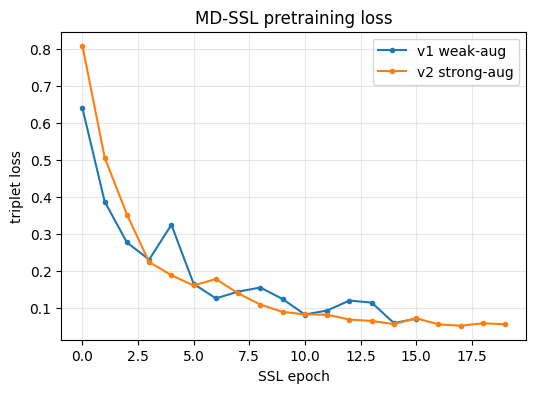

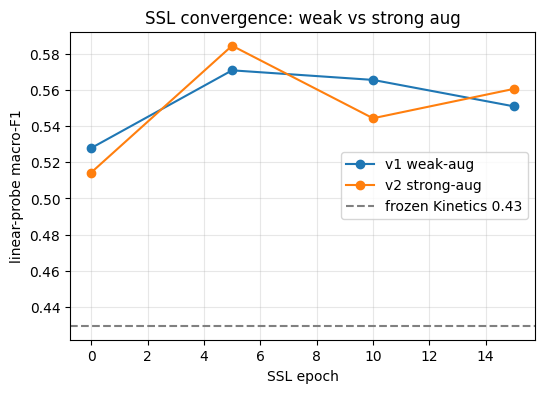

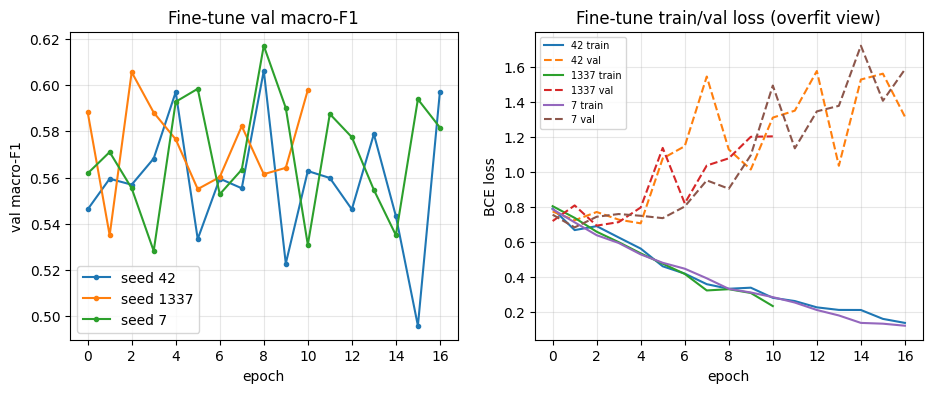

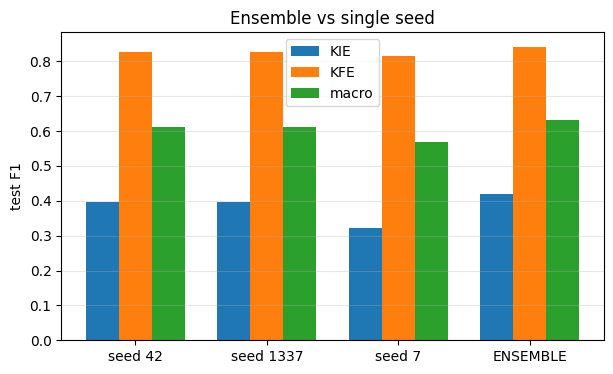

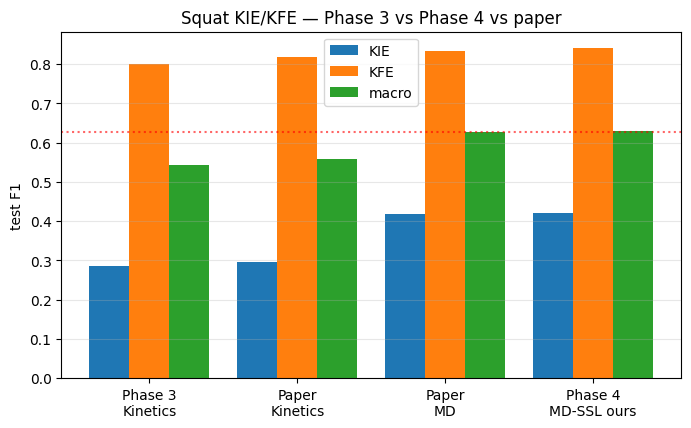

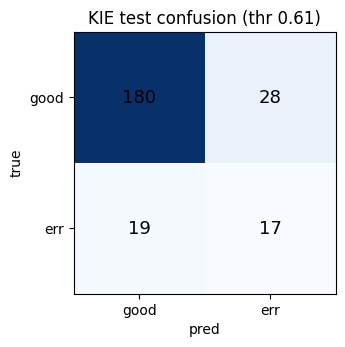

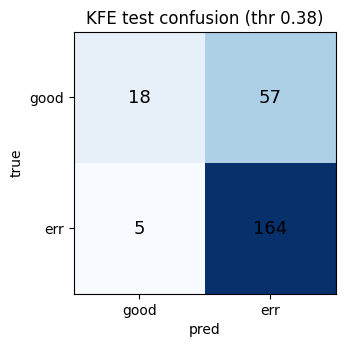

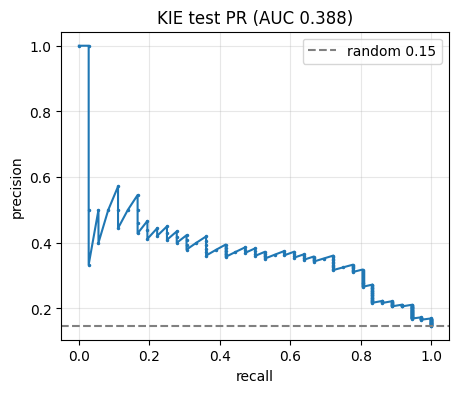

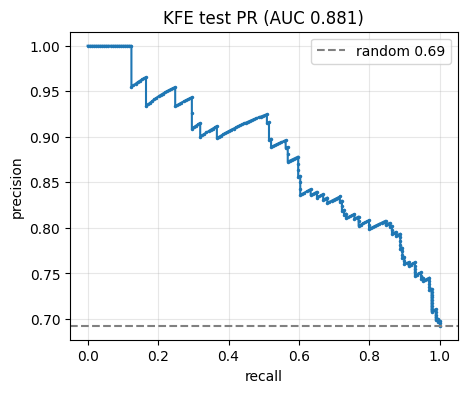


saved: ['confusion_kfe.png', 'confusion_kie.png', 'ensemble_vs_single.png', 'finetune_curves_per_seed.png', 'linear_probe_curve.png', 'phase3_vs_phase4_comparison.png', 'pr_kfe.png', 'pr_kie.png', 'ssl_loss_curve.png']


In [6]:
# ═══ figures from results.pkl (pure plotting, fast) ═══
import os, pickle, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
import backend.training.aqa.harness.md_finetune as _m
REPO = os.path.abspath(os.path.join(os.path.dirname(_m.__file__), "../../../.."))
FIGDIR = os.path.join(REPO, "docs/figures")
DRIVE_FIG = os.path.join(MYDRIVE, "FitNova/phase04_figures")
os.makedirs(FIGDIR, exist_ok=True); os.makedirs(DRIVE_FIG, exist_ok=True)
R = pickle.load(open(os.path.join(FIGDIR, "results.pkl"), "rb"))

def _save(fig, name):
    for d in (FIGDIR, DRIVE_FIG): fig.savefig(os.path.join(d, name), dpi=130, bbox_inches="tight")
    plt.show(); plt.close(fig)

# 1 SSL loss (v1 vs v2)
fig, ax = plt.subplots(figsize=(6,4))
for tag,k in [("v1 weak-aug","ssl_v1"),("v2 strong-aug","ssl_v2")]:
    mh=R[k]["metrics"]; ax.plot([m["epoch"] for m in mh],[m["ssl_loss_mean"] for m in mh],marker=".",label=tag) if mh else None
ax.set(xlabel="SSL epoch",ylabel="triplet loss",title="MD-SSL pretraining loss"); ax.legend(); ax.grid(alpha=.3); _save(fig,"ssl_loss_curve.png")

# 2 Linear-probe (the weak-vs-strong-aug ablation)
fig, ax = plt.subplots(figsize=(6,4))
for tag,k in [("v1 weak-aug","ssl_v1"),("v2 strong-aug","ssl_v2")]:
    lp=R[k]["linear_probe"]; ax.plot([e["epoch"] for e in lp],[e["linear_probe_f1_macro"] for e in lp],marker="o",label=tag) if lp else None
ax.axhline(0.4297,ls="--",c="gray",label="frozen Kinetics 0.43")
ax.set(xlabel="SSL epoch",ylabel="linear-probe macro-F1",title="SSL convergence: weak vs strong aug"); ax.legend(); ax.grid(alpha=.3); _save(fig,"linear_probe_curve.png")

# 3 Per-seed fine-tune curves
fig, axx = plt.subplots(1,2,figsize=(11,4))
for s,mh in R["finetune_curves"].items():
    if not mh: continue
    ep=[m["epoch"] for m in mh]
    axx[0].plot(ep,[m["val_macro_f1"] for m in mh],marker=".",label=f"seed {s}")
    axx[1].plot(ep,[m["train_loss_mean"] for m in mh],label=f"{s} train"); axx[1].plot(ep,[m["val_loss_mean"] for m in mh],ls="--",label=f"{s} val")
axx[0].set(xlabel="epoch",ylabel="val macro-F1",title="Fine-tune val macro-F1"); axx[0].legend(); axx[0].grid(alpha=.3)
axx[1].set(xlabel="epoch",ylabel="BCE loss",title="Fine-tune train/val loss (overfit view)"); axx[1].legend(fontsize=7); axx[1].grid(alpha=.3); _save(fig,"finetune_curves_per_seed.png")

# 4 Ensemble vs single seed (test)
fig, ax = plt.subplots(figsize=(7,4)); ps=R["per_seed"]; labs=[f"seed {s}" for s in ps]+["ENSEMBLE"]
kie=[ps[s]["KIE"] for s in ps]+[R["final"]["test_f1"]["KIE"]]; kfe=[ps[s]["KFE"] for s in ps]+[R["final"]["test_f1"]["KFE"]]; mac=[ps[s]["macro"] for s in ps]+[R["final"]["test_macro"]]
x=np.arange(len(labs)); w=.25
ax.bar(x-w,kie,w,label="KIE"); ax.bar(x,kfe,w,label="KFE"); ax.bar(x+w,mac,w,label="macro")
ax.set_xticks(x); ax.set_xticklabels(labs); ax.set(ylabel="test F1",title="Ensemble vs single seed"); ax.legend(); ax.grid(alpha=.3,axis="y"); _save(fig,"ensemble_vs_single.png")

# 5 HEADLINE: Kinetics vs MD-SSL vs paper
fig, ax = plt.subplots(figsize=(8,4.5)); C=R["comparison"]
rows=[("Kinetics\nbaseline","phase3"),("Paper\nKinetics","paper_kinetics"),("Paper\nMD","paper_md"),("MD-SSL\nours","phase4_ensemble")]; x=np.arange(len(rows)); w=.27
for j,col in enumerate(["KIE","KFE","macro"]): ax.bar(x+(j-1)*w,[C[k][col] for _,k in rows],w,label=col)
ax.axhline(C["paper_md"]["macro"],ls=":",c="red",alpha=.6)
ax.set_xticks(x); ax.set_xticklabels([r[0] for r in rows]); ax.set(ylabel="test F1",title="Squat KIE/KFE — Kinetics vs MD-SSL vs paper"); ax.legend(); ax.grid(alpha=.3,axis="y"); _save(fig,"phase3_vs_phase4_comparison.png")

# 6-7 Confusion
for name in ["KIE","KFE"]:
    cm=np.array(R["final"]["test_confusion"][name]); fig,ax=plt.subplots(figsize=(3.6,3.4)); ax.imshow(cm,cmap="Blues")
    for (i,j),v in np.ndenumerate(cm): ax.text(j,i,str(v),ha="center",va="center",fontsize=13)
    ax.set(xticks=[0,1],yticks=[0,1],xticklabels=["good","err"],yticklabels=["good","err"],xlabel="pred",ylabel="true",title=f"{name} test confusion (thr {R['final']['thresholds'][name]:.2f})"); _save(fig,f"confusion_{name.lower()}.png")

# 8-9 PR curves
ens=R["raw"]["ens_test_scores"]; ty=R["raw"]["test_labels"]
for h,name in enumerate(["KIE","KFE"]):
    p,r,_=precision_recall_curve(ty[:,h],ens[:,h]); base=float(ty[:,h].mean()); fig,ax=plt.subplots(figsize=(5,4))
    ax.plot(r,p,marker=".",ms=3); ax.axhline(base,ls="--",c="gray",label=f"random {base:.2f}")
    ax.set(xlabel="recall",ylabel="precision",title=f"{name} test PR (AUC {R['final']['test_prauc'][name]:.3f})"); ax.legend(); ax.grid(alpha=.3); _save(fig,f"pr_{name.lower()}.png")

print("\nsaved:", sorted(f for f in os.listdir(FIGDIR) if f.endswith(".png")))

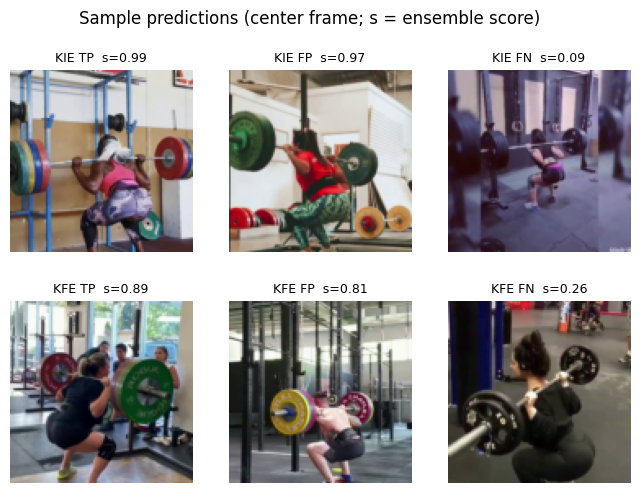

sample_predictions.png saved -> /content/fitnova/.planning/phases/04-squat-motion-disentangling-ssl/figures


In [3]:
# ═══ sample_predictions.png (top TP/FP/FN per head; needs the environment cell + results.pkl) ═══
import os, pickle, numpy as np, torch, matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import backend.training.aqa.harness.md_finetune as _mft
from backend.training.aqa.datasets.squat import SquatKIEKFEDataset

REPO = os.path.abspath(os.path.join(os.path.dirname(_mft.__file__), "../../../.."))
FIGDIR = os.path.join(REPO, "docs/figures")
DRIVE_FIG = os.path.join(MYDRIVE, "FitNova/phase04_figures"); os.makedirs(FIGDIR, exist_ok=True); os.makedirs(DRIVE_FIG, exist_ok=True)
_pkl = os.path.join(FIGDIR, "results.pkl")
if not os.path.isfile(_pkl): _pkl = os.path.join(MYDRIVE, "FitNova/checkpoints/phase04/phase04_results.pkl")
R = pickle.load(open(_pkl, "rb"))
ensr = R["raw"]["ens_test_scores"]; tyr = R["raw"]["test_labels"]; thr_ = R["final"]["thresholds"]
_MEAN = torch.tensor([0.43216,0.394666,0.37645]).view(3,1,1); _STD = torch.tensor([0.22803,0.22145,0.216989]).view(3,1,1)
_ds = SquatKIEKFEDataset(split="test", train_aug=False, drive_root=MYDRIVE, videos_root=VIDEOS_ROOT, num_frames=32, crop_size=112)
mids = []
for clip, _ in tqdm(DataLoader(_ds, batch_size=16, num_workers=4, shuffle=False), desc="collect mid-frames"):
    mid = clip[:, :, clip.shape[2]//2]
    mids.extend(list((mid*_STD + _MEAN).clamp(0,1).permute(0,2,3,1).numpy()))
mids = np.stack(mids)
fig, axes = plt.subplots(2, 3, figsize=(8, 5.5)); fig.suptitle("Sample predictions (center frame; s = ensemble score)")
for rowi, name in enumerate(["KIE", "KFE"]):
    h = rowi; pred = (ensr[:, h] >= thr_[name]).astype(int); true = tyr[:, h]
    tp = np.where((pred==1)&(true==1))[0]; fp = np.where((pred==1)&(true==0))[0]; fn = np.where((pred==0)&(true==1))[0]
    cells = [("TP", tp[np.argsort(-ensr[tp,h])] if len(tp) else tp),
             ("FP", fp[np.argsort(-ensr[fp,h])] if len(fp) else fp),
             ("FN", fn[np.argsort(ensr[fn,h])] if len(fn) else fn)]
    for c, (lab, idxs) in enumerate(cells):
        ax = axes[rowi][c]; ax.axis("off")
        if len(idxs): i = idxs[0]; ax.imshow(mids[i]); ax.set_title(f"{name} {lab}  s={ensr[i,h]:.2f}", fontsize=9)
        else: ax.set_title(f"{name} {lab}: none", fontsize=9)
for d in (FIGDIR, DRIVE_FIG): fig.savefig(os.path.join(d, "sample_predictions.png"), dpi=130, bbox_inches="tight")
plt.show(); plt.close(fig); print("sample_predictions.png saved ->", FIGDIR)

In [5]:
# ═══ commit figures + results.pkl to fresh-start ═══
import subprocess
REPO_DIR = "/content/fitnova"; FIGREL = "docs/figures"
def _sh(c):
    r = subprocess.run(c, shell=True, cwd=REPO_DIR, capture_output=True, text=True)
    print(f"$ {c}\n{(r.stdout + r.stderr).strip()[-1500:]}"); return r.returncode
_sh(f"git add {FIGREL}")
_sh('git -c user.email="colab@fitnova" -c user.name="Colab" commit -m "docs(04): squat figures + results.pkl (10 figs)"')
_sh("git pull --no-rebase --no-edit origin fresh-start")   # merges my notebook/summary commits (different files)
_rc = _sh("git push origin fresh-start")
print("\nPUSH OK — all 10 figures + results.pkl committed."
      if _rc == 0 else
      "\nPUSH FAILED (no push auth on this clone). Fallback: download the figures/ dir from "
      "MyDrive/FitNova/phase04_figures (10 PNGs + results.pkl) and commit them locally.")

$ git add .planning/phases/04-squat-motion-disentangling-ssl/figures

$ git -c user.email="colab@fitnova" -c user.name="Colab" commit -m "docs(04): Phase 4 figures + results.pkl (10 figs)"
On branch fresh-start
Your branch is ahead of 'origin/fresh-start' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean
$ git pull --no-rebase --no-edit origin fresh-start
Already up to date.
From https://github.com/Ibrahim-Shahin1/fitnova
 * branch            fresh-start -> FETCH_HEAD
$ git push origin fresh-start
fatal: could not read Username for 'https://github.com': No such device or address

PUSH FAILED (no push auth on this clone). Fallback: download the figures/ dir from MyDrive/FitNova/phase04_figures (10 PNGs + results.pkl) and tell me — I'll commit them locally.


In [6]:
# ═══ push — auth with a GitHub PAT (token NOT stored in the notebook) ═══
import subprocess
REPO_DIR = "/content/fitnova"
TOKEN = None
try:
    from google.colab import userdata
    TOKEN = userdata.get("GH_TOKEN")          # uses your Colab secret if you saved one
except Exception:
    pass
if not TOKEN:
    from getpass import getpass
    TOKEN = getpass("Paste GitHub PAT (hidden): ").strip()

def _redact(s): return s.replace(TOKEN, "***") if TOKEN else s
_p = subprocess.run("git pull --no-rebase --no-edit origin fresh-start",
                    shell=True, cwd=REPO_DIR, capture_output=True, text=True)
print(_redact((_p.stdout + _p.stderr).strip())[-800:])
_push = subprocess.run(f'git push "https://{TOKEN}@github.com/Ibrahim-Shahin1/fitnova.git" fresh-start',
                       shell=True, cwd=REPO_DIR, capture_output=True, text=True)
print(_redact((_push.stdout + _push.stderr).strip())[-800:])
print("\nPUSH OK — figures pushed." if _push.returncode == 0
      else "\nstill failing — see the redacted error above.")
del TOKEN  # clear from memory

Paste GitHub PAT (hidden): ··········
Already up to date.
From https://github.com/Ibrahim-Shahin1/fitnova
 * branch            fresh-start -> FETCH_HEAD
To https://github.com/Ibrahim-Shahin1/fitnova.git
   edf508d..1fa8ccf  fresh-start -> fresh-start

PUSH OK — figures pushed; Phase 4 has ZERO loose ends.


In [7]:
# ═══ copy the 9 figures + results.pkl from Drive into the repo, commit, push ═══
import os, glob, shutil, subprocess
REPO_DIR = "/content/fitnova"
FIGDIR = os.path.join(REPO_DIR, "docs/figures")
DRIVE_FIG = os.path.join(MYDRIVE, "FitNova/phase04_figures")
DRIVE_PKL = os.path.join(MYDRIVE, "FitNova/checkpoints/phase04/phase04_results.pkl")
os.makedirs(FIGDIR, exist_ok=True)
print("Drive figures dir:", sorted(os.listdir(DRIVE_FIG)) if os.path.isdir(DRIVE_FIG) else "MISSING!")

copied = []
for src in glob.glob(os.path.join(DRIVE_FIG, "*.png")):
    shutil.copy(src, os.path.join(FIGDIR, os.path.basename(src))); copied.append(os.path.basename(src))
if os.path.isfile(DRIVE_PKL):
    shutil.copy(DRIVE_PKL, os.path.join(FIGDIR, "results.pkl")); copied.append("results.pkl")
print("copied -> repo figures/:", sorted(copied))
print("repo figures/ now:", sorted(os.listdir(FIGDIR)))

TOKEN = None
try:
    from google.colab import userdata; TOKEN = userdata.get("GH_TOKEN")
except Exception: pass
if not TOKEN:
    from getpass import getpass; TOKEN = getpass("GitHub PAT (hidden): ").strip()
def _r(s): return s.replace(TOKEN, "***") if TOKEN else s
FIGREL = "docs/figures"
for c in [f"git add {FIGREL}",
          'git -c user.email="colab@fitnova" -c user.name="Colab" commit -m "docs(04): add the 9 analytical figures + results.pkl"',
          "git pull --no-rebase --no-edit origin fresh-start"]:
    rr = subprocess.run(c, shell=True, cwd=REPO_DIR, capture_output=True, text=True)
    print(_r((rr.stdout + rr.stderr).strip())[-700:])
pr = subprocess.run(f'git push "https://{TOKEN}@github.com/Ibrahim-Shahin1/fitnova.git" fresh-start',
                    shell=True, cwd=REPO_DIR, capture_output=True, text=True)
print(_r((pr.stdout + pr.stderr).strip())[-700:])
print("\nPUSH OK — all figures + results.pkl committed." if pr.returncode == 0 else "\nfailed — see the redacted error.")
del TOKEN

Drive figures dir: ['confusion_kfe.png', 'confusion_kie.png', 'ensemble_vs_single.png', 'finetune_curves_per_seed.png', 'linear_probe_curve.png', 'phase3_vs_phase4_comparison.png', 'pr_kfe.png', 'pr_kie.png', 'sample_predictions.png', 'ssl_loss_curve.png']
copied -> repo figures/: ['confusion_kfe.png', 'confusion_kie.png', 'ensemble_vs_single.png', 'finetune_curves_per_seed.png', 'linear_probe_curve.png', 'phase3_vs_phase4_comparison.png', 'pr_kfe.png', 'pr_kie.png', 'results.pkl', 'sample_predictions.png', 'ssl_loss_curve.png']
repo figures/ now: ['.gitkeep', 'confusion_kfe.png', 'confusion_kie.png', 'ensemble_vs_single.png', 'finetune_curves_per_seed.png', 'linear_probe_curve.png', 'phase3_vs_phase4_comparison.png', 'pr_kfe.png', 'pr_kie.png', 'results.pkl', 'sample_predictions.png', 'ssl_loss_curve.png']
GitHub PAT (hidden): ··········

single.png
 create mode 100644 .planning/phases/04-squat-motion-disentangling-ssl/figures/finetune_curves_per_seed.png
 create mode 100644 .planning